# QEC on a rotated planar surface code — the **PsiQDK** view: logical simulation + fault‑tolerant resource estimation

Notebooks 1–7 built a *physical* emulator of a rotated‑planar surface code in **ITensor/Julia**: real
data and ancilla qubits carried as an MPS, stabiliser/syndrome extraction, an MWPM (sliding‑window)
decoder, injected Pauli/measurement noise, and a per‑shot logical‑failure oracle giving a logical error
rate $p_L$. That stack answers a *physics* question: **does the code, decoded, survive the noise?**

This notebook rebuilds the same **logical circuits** — a single logical qubit, two‑qubit Cliffords, a
magic‑state $T$ gate, and a general non‑Clifford runner — but in **PsiQDK** (PsiQuantum's Quantum
Development Kit: `psiqworkbench` + `workbench_algorithms` + `bartiq`). PsiQDK lives at a **different rung
of the abstraction ladder**, and it is important to be honest about that up front.

> **PsiQDK is a *logical‑level* fault‑tolerant design kit, not a physical QEC simulator.**
> It has **no** physical data qubits, **no** stabiliser rounds, **no** syndrome extraction, and **no**
> decoder — those primitives simply do not exist in the package. Instead it (a) *simulates the logical
> circuit* on an optimised C++ backend (statevector / expectation values), and (b) *estimates the
> fault‑tolerant cost* of running that circuit — T‑count, active volume, and, layered on top, the
> physical‑qubit and space‑time footprint needed to reach a target logical error rate.

So the ITensor question *"can we decode this code below threshold?"* becomes, in PsiQDK, the complementary
question **"given that a decoder *can* hit a target $p_L$, how big and how long is the fault‑tolerant
computation?"**  The target logical error rate is an **input** here, not an output. The two views meet
at exactly the surface‑code threshold formula from notebook 7 — we close the loop in §7 below.

## §0 — The abstraction‑layer map

| ITensor engine (notebooks 1–7) | PsiQDK analogue (this notebook) |
|---|---|
| physical data + ancilla qubits carried in an MPS | logical qubits (`Qubits` registers) — no physical qubits |
| stabiliser generators, syndrome‑extraction rounds | *(below the API — not simulated)* |
| MWPM / sliding‑window decoder, artificial defects | *(fault tolerance is **estimated / compiled**, not decoded)* |
| transversal CNOT, `H⊗ⁿ`+rotation, `S`/`T` by teleportation | `QPU.had` / `QPU.x` (cond.) / `QPU.s` / `QPU.t` logical ops |
| exact ±1 readout oracle, `joint_expect` | `QPU.pull_state()` → statevector → ⟨ZZ⟩, ⟨XX⟩ … |
| inject Pauli noise at rate `p`, measure logical error `p_L` | **target `p_L` is an input** to resource estimation |
| *"does the code survive the noise?"* | *"how many physical qubits / how much space‑time to hit `p_L`?"* |

Everything below the double line in that table is what PsiQDK *adds*: **cost**. Everything above it is
what it *abstracts away*. We reuse the **exact same gate‑list circuit format** as the ITensor non‑Clifford
runner (notebook 4 §6) so the two stacks are directly comparable — that shared format is also the spine
of the companion comparison notebook.

In [1]:
import warnings; warnings.filterwarnings("ignore")   # silence WB deprecation chatter
from importlib.metadata import version
import numpy as np
import psiqworkbench as wb
from psiqworkbench import QPU, Qubits
from psiqworkbench.resource_estimation.qre import resource_estimator

print("psiqdk          ", version("psiqdk"))
print("psiqdk-workbench", version("psiqdk-workbench"))
print("numpy           ", np.__version__)

psiqdk           2.1.0
psiqdk-workbench 4.48.4
numpy            2.5.1


## §1 — A single logical qubit and the `QPU`

The ITensor notebook 1 *encoded* one logical qubit into a $d=3$ patch and prepared $|0\rangle_L$ by
projective stabiliser measurement. In PsiQDK a logical qubit is just an entry in a `Qubits` register on a
`QPU`. `reset(n)` sizes the machine, `Qubits(n, name, qc)` allocates a register, and `write(0)` prepares
$|0\rangle$. Gates act on **masks** (`q[i].mask()`), and `pull_state()` returns the logical statevector.

Preparing $|+\rangle_L$ — the ITensor "prepare‑in‑$X$" experiment — is a single Hadamard.

In [2]:
qc = QPU(); qc.reset(1)
q  = Qubits(1, "q", qc); qc.write(0)          # |0>_L
print("state after prep |0>:"); qc.print_state_vector()

qc.had(q[0].mask())                            # -> |+>_L
print("\nstate after H (|+>_L):"); qc.print_state_vector()

state after prep |0>:
|q>
|0>    1.000000+0.000000j

state after H (|+>_L):
|q>
|0>    0.707107+0.000000j
|1>    0.707107+0.000000j


'|q>\n|0>    0.707107+0.000000j\n|1>    0.707107+0.000000j\n'

## §2 — Two logical qubits and Clifford gates: a Bell pair

Notebook 3 built an entangled two‑qubit logical state with a **transversal CNOT**. The CNOT here is a
Pauli‑X on the *target* register **conditioned** on the *control* register — `qc.x(target, control)`
(the `condition_mask` is the second argument). `H` on the control followed by CNOT gives a clean Bell pair
$(\lvert00\rangle+\lvert11\rangle)/\sqrt2$, for which $\langle ZZ\rangle=\langle XX\rangle=+1$.

In [3]:
qc = QPU(); qc.reset(2)
q  = Qubits(2, "q", qc); qc.write(0)
qc.had(q[0].mask())               # H on control (patch 1)
qc.x(q[1].mask(), q[0].mask())    # CNOT: X on target (patch 2) conditioned on control (patch 1)
qc.print_state_vector()

# expectation values from the pulled statevector (patch 1 = q0 = least-significant bit)
I2=np.eye(2); X=np.array([[0,1],[1,0]],complex); Y=np.array([[0,-1j],[1j,0]]); Z=np.diag([1,-1.]).astype(complex)
P={"I":I2,"X":X,"Y":Y,"Z":Z}
def expect(psi, b1, b2):          # <P1 P2> ; op = kron(op_on_q1, op_on_q0)
    return float(np.real(np.vdot(psi, np.kron(P[b2], P[b1]) @ psi)))
psi = np.asarray(qc.pull_state()).ravel()
print(f"\n<ZZ> = {expect(psi,'Z','Z'):+.3f}   <XX> = {expect(psi,'X','X'):+.3f}   (Bell pair)")

|q>
|0>    0.707107+0.000000j
|3>    0.707107+0.000000j

<ZZ> = +1.000   <XX> = +1.000   (Bell pair)


## §3 — Magic states and the `T` gate

Universality needs a non‑Clifford gate. Notebook 4 injected a $T$ by **teleporting through a magic state**
$|A\rangle$ prepared on a third patch — the whole point of the magic‑state machinery. PsiQDK exposes the
same physics as a one‑liner, `qc.t(...)`: underneath, the compiler realises the rotation by magic‑state
injection / rotation‑catalyst gadgets (the `ppr`, `pygridsynth`, and `effective_rotation_epsilon`
machinery), and — crucially — it **counts** each one, because $T$ (magic‑state) gates dominate the
fault‑tolerant cost. That count reappears in §6.

The canonical **magic Bell** state $\text{CNOT}\,(T\otimes I)\,(H\otimes I)\lvert00\rangle
= (\lvert00\rangle + e^{i\pi/4}\lvert11\rangle)/\sqrt2$ has the tell‑tale
$\langle XX\rangle = \cos(\pi/4) = 0.707$ — exactly the value validated on the ITensor engine.

In [4]:
qc = QPU(); qc.reset(2)
q  = Qubits(2, "q", qc); qc.write(0)
qc.had(q[0].mask()); qc.t(q[0].mask()); qc.x(q[1].mask(), q[0].mask())   # H1; T1; CNOT
psi = np.asarray(qc.pull_state()).ravel()
print("magic Bell amplitudes:", np.round(psi, 3))
print(f"<ZZ> = {expect(psi,'Z','Z'):+.3f}  (expect +1)")
print(f"<XX> = {expect(psi,'X','X'):+.3f}  (expect cos(pi/4) = {np.cos(np.pi/4):.3f})")
print(f"<YY> = {expect(psi,'Y','Y'):+.3f}  (expect -0.707)")

magic Bell amplitudes: [0.707+0.j  0.   +0.j  0.   +0.j  0.5  +0.5j]
<ZZ> = +1.000  (expect +1)
<XX> = +0.707  (expect cos(pi/4) = 0.707)
<YY> = -0.707  (expect -0.707)


## §4 — A general non‑Clifford circuit runner

Exactly as in notebook 4 §6, a circuit is a **list of gate tuples** on patches `1` and `2`, and both
patches always start in $|0\rangle$ — you build any other input with leading gates:

* single‑qubit: `("H",p) ("X",p) ("Z",p) ("S",p) ("T",p)` on patch `p`
* two‑qubit: `("CNOT", control, target)`

`run_wb(circuit)` returns the logical statevector; read it out with `expect(psi, "Z", "Z")` etc. This is
the byte‑for‑byte analogue of the ITensor `run_circuit` / `corr` pair, and uses the identical circuit
spec so the same programs run on both stacks.

In [5]:
def build(circuit, n=2):
    # Apply a gate-list circuit (1-indexed patches) to a fresh QPU; return (qc, qubits).
    qc = QPU(); qc.reset(n)
    q = Qubits(n, "q", qc); qc.write(0)                 # both patches |0>
    for gate in circuit:
        name, tgt = gate[0], gate[1]
        if   name == "H": qc.had(q[tgt-1].mask())
        elif name == "X": qc.x(q[tgt-1].mask())
        elif name == "Z": qc.z(q[tgt-1].mask())
        elif name == "S": qc.s(q[tgt-1].mask())
        elif name == "T": qc.t(q[tgt-1].mask())
        elif name == "CNOT":
            c, t = gate[1], gate[2]
            qc.x(q[t-1].mask(), q[c-1].mask())          # X on target conditioned on control
        else: raise ValueError(f"unknown gate {name}")
    return qc, q

def run_wb(circuit):
    qc, _ = build(circuit)
    return np.asarray(qc.pull_state()).ravel()

print("runner ready")

runner ready


## §5 — Validation against an exact 2‑qubit reference

The same check notebook 4 ran against a $4\times4$ statevector simulator, now against a numpy reference
built with the **identical** patch‑1‑is‑LSB convention. Because logical simulation is exact (no shot
noise), every value must match the reference to machine precision.

In [6]:
# ---- exact 2-qubit statevector reference (patch 1 = q0 = LSB) ----
_H=np.array([[1,1],[1,-1]],complex)/np.sqrt(2); _S=np.diag([1,1j]); _T=np.diag([1,np.exp(1j*np.pi/4)])
def _1q(g,p): return np.kron(I2,g) if p==1 else np.kron(g,I2)
def _cnot(c,t):
    M=np.zeros((4,4),complex)
    for b in range(4):
        bits=[(b>>0)&1,(b>>1)&1]
        if bits[c-1]: bits[t-1]^=1
        M[bits[0]+2*bits[1], b]=1
    return M
def ref_state(circuit):
    psi=np.array([1,0,0,0],complex)
    for gate in circuit:
        if gate[0]=="CNOT": M=_cnot(gate[1],gate[2])
        else: M=_1q({"X":X,"Z":Z,"H":_H,"S":_S,"T":_T}[gate[0]], gate[1])
        psi=M@psi
    return psi

# ---- the same demo battery as notebook 4 §7 ----
demos = [
    ("H1;CNOT        (Bell, H on CONTROL)",     [("H",1),("CNOT",1,2)]),
    ("H2;CNOT        (product)",                [("H",2),("CNOT",1,2)]),
    ("H1;CNOT;H1     (H after CNOT)",           [("H",1),("CNOT",1,2),("H",1)]),
    ("H1;H1;CNOT     (HH = I)",                 [("H",1),("H",1),("CNOT",1,2)]),
    ("H1;CNOT;H1;H2  (H both sides)",           [("H",1),("CNOT",1,2),("H",1),("H",2)]),
    ("T1;CNOT        (no leading H: no magic)", [("T",1),("CNOT",1,2)]),
    ("H1;T1;CNOT     (magic Bell)",             [("H",1),("T",1),("CNOT",1,2)]),
    ("H1;S1;H1;CNOT",                           [("H",1),("S",1),("H",1),("CNOT",1,2)]),
    ("H1;H2;T1;T2;CNOT",                        [("H",1),("H",2),("T",1),("T",2),("CNOT",1,2)]),
]
print(f"{'circuit':40}{'ZZ  wb / ref':22}{'XX  wb / ref':22}ok")
print("-"*88); allok=True
for name,circ in demos:
    r=ref_state(circ); p=run_wb(circ)
    zz,rzz=expect(p,'Z','Z'),expect(r,'Z','Z'); xx,rxx=expect(p,'X','X'),expect(r,'X','X')
    ok=abs(zz-rzz)<1e-9 and abs(xx-rxx)<1e-9; allok&=ok
    print(f"{name:40}{f'{zz:+.3f} / {rzz:+.3f}':22}{f'{xx:+.3f} / {rxx:+.3f}':22}{'OK' if ok else 'MISMATCH'}")
print("\nALL EXACT:", allok)

circuit                                 ZZ  wb / ref          XX  wb / ref          ok
----------------------------------------------------------------------------------------
H1;CNOT        (Bell, H on CONTROL)     +1.000 / +1.000       +1.000 / +1.000       OK
H2;CNOT        (product)                +0.000 / +0.000       +0.000 / +0.000       OK
H1;CNOT;H1     (H after CNOT)           +0.000 / +0.000       +0.000 / +0.000       OK
H1;H1;CNOT     (HH = I)                 +1.000 / +1.000       +0.000 / -0.000       OK
H1;CNOT;H1;H2  (H both sides)           +1.000 / +1.000       +1.000 / +1.000       OK
T1;CNOT        (no leading H: no magic) +1.000 / +1.000       +0.000 / +0.000       OK
H1;T1;CNOT     (magic Bell)             +1.000 / +1.000       +0.707 / +0.707       OK
H1;S1;H1;CNOT                           +1.000 / +1.000       +0.000 / +0.000       OK
H1;H2;T1;T2;CNOT                        +0.000 / +0.000       +0.707 / +0.707       OK

ALL EXACT: True


## §6 — The QEC analogue: fault‑tolerant **resource estimation**

Here is where PsiQDK does the job the ITensor decoder does — but from the opposite direction. The ITensor
stack *measures* whether a fixed‑distance code survives a given physical noise rate. PsiQDK instead *reads
off the cost* of the logical program, in the currency that actually sets the size of a fault‑tolerant
machine:

* **`t_gates`** — the number of magic states consumed. $T$/rotation gates dominate FTQC cost because each
  one needs a distilled magic state; Clifford gates are (nearly) free by comparison.
* **`active_volume`** — PsiQuantum's space‑time cost metric (logical‑block·cycles), the quantity their
  active‑volume architecture is designed to minimise. It is the honest "how much fault‑tolerant work".
* **`qubit_highwater`** — peak *logical* qubits.

Notice the Clifford‑only circuits cost `t_gates = 0` and a small active volume, while every $T$ adds a
large fixed chunk of volume (magic‑state distillation) — the resource fingerprint of non‑Cliffordness.

In [7]:
def resources(circuit):
    qc,_ = build(circuit)
    return resource_estimator(qc).resources()

print(f"{'circuit':40}{'t_gates':>9}{'active_volume':>16}{'logical qubits':>16}")
print("-"*81)
for name,circ in demos:
    r=resources(circ)
    print(f"{name:40}{r['t_gates']:>9}{r['active_volume']:>16.1f}{r['qubit_highwater']:>16}")

circuit                                   t_gates   active_volume  logical qubits
---------------------------------------------------------------------------------
H1;CNOT        (Bell, H on CONTROL)             0             7.0               2
H2;CNOT        (product)                        0             7.0               2
H1;CNOT;H1     (H after CNOT)                   0            10.0               2
H1;H1;CNOT     (HH = I)                         0            10.0               2
H1;CNOT;H1;H2  (H both sides)                   0            13.0               2
T1;CNOT        (no leading H: no magic)         1            32.5               2
H1;T1;CNOT     (magic Bell)                     1            35.5               2
H1;S1;H1;CNOT                                   0            15.0               2
H1;H2;T1;T2;CNOT                                2            67.0               2


## §7 — From logical resources to a physical footprint (closing the loop with notebook 7)

PsiQDK's `active_volume` and `t_gates` are *logical* costs. To turn them into **physical qubits and
wall‑clock time** we need exactly the surface‑code physics notebook 7 measured. Below threshold, the
per‑round logical error rate of a distance‑$d$ patch is

$$p_L(d)\;\approx\;A\left(\frac{p}{p_\text{th}}\right)^{\lfloor d/2\rfloor+1},$$

with circuit-level threshold $p_\text{th}\approx1\%$ (notebook 7 §7/§10). This is the
**per-logical-operation** logical error rate — exactly what notebook 7 *measures* for a $d=3$ memory. A
rotated-planar patch uses $2d^2-1$ physical qubits, so we pick the smallest odd $d$ whose $p_L(d)$ stays
under a **target** $p_L^{\text{target}}$, then multiply out the footprint.

At $p=10^{-3}$ each step in $d$ buys one factor of $p/p_\text{th}=0.1$, so the first two rungs are the
distances your other work uses — **$d=3$** (notebook 7) at target $p_L\approx10^{-3}$ and **$d=5$**
(`8.Scaling`) at $p_L\approx10^{-4}$ — which is where a future head-to-head against their *measured* $p_L$
slots in. A *full algorithm* multiplies $p_L(d)$ by the active volume $V$ (every logical block must
survive), which is why deep computations push $d$ higher; we report that as the `total err` column.

This is the *standard* surface-code cost model laid on top of PsiQDK's native active-volume output — the
same physics as notebook 7, run in the forward direction: **noise + target ⇒ code distance ⇒ hardware.**

In [8]:
P_TH, A = 1e-2, 0.1                                    # circuit-level threshold, prefactor (nb7 §10)
def p_L(d, p): return A * (p / P_TH) ** ((d + 1) // 2)  # logical error PER logical operation (odd d)
def distance_for(p, target):
    d = 3
    while p_L(d, p) > target*(1+1e-6) and d < 99: d += 2   # tol avoids fp boundary off-by-one
    return d
def footprint(circuit, p, target, cycle_us=1.0):
    r = resources(circuit); V = r["active_volume"]; nq = r["qubit_highwater"]
    d = distance_for(p, target)
    return dict(V=V, t=r["t_gates"], d=d, phys=nq*(2*d*d-1),        # distillation factories extra
                total_err=V*p_L(d, p), runtime_us=V*d*cycle_us)

magic = [("H",1),("T",1),("CNOT",1,2)]
print("distance ladder at p = 1e-3  (per-operation logical error rate)")
print(f"{'code dist d':>12}{'p_L per op':>13}{'phys qubits/patch':>20}   regime")
print("-"*57)
for d, tag in [(3,'notebook 7'),(5,'8.Scaling'),(7,''),(9,'')]:
    print(f"{d:>12}{p_L(d,1e-3):>13.1e}{2*d*d-1:>20}   {tag}")

print("\nmagic-Bell footprint at target p_L = 1e-4  (-> d=5), a few physical rates")
print(f"{'phys err p':>12}{'distance d':>12}{'phys qubits':>14}{'runtime (us)':>14}")
print("-"*52)
for p in (5e-4, 1e-3, 3e-3):
    f = footprint(magic, p, 1e-4)
    print(f"{p:>12.0e}{f['d']:>12}{f['phys']:>14}{f['runtime_us']:>14.1f}")

distance ladder at p = 1e-3  (per-operation logical error rate)
 code dist d   p_L per op   phys qubits/patch   regime
---------------------------------------------------------
           3      1.0e-03                  17   notebook 7
           5      1.0e-04                  49   8.Scaling
           7      1.0e-05                  97   
           9      1.0e-06                 161   

magic-Bell footprint at target p_L = 1e-4  (-> d=5), a few physical rates
  phys err p  distance d   phys qubits  runtime (us)
----------------------------------------------------
       5e-04           5            98         177.5
       1e-03           5            98         177.5
       3e-03          11           482         390.5


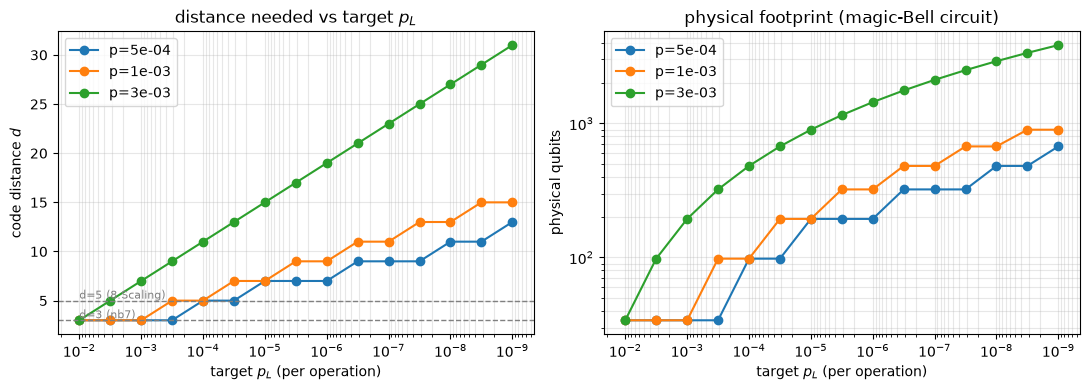

In [9]:
import matplotlib.pyplot as plt
targets = np.logspace(-2, -9, 15)                       # modest targets -> d in the 3..15 range
fig, ax = plt.subplots(1, 2, figsize=(11,4))
for p in (5e-4, 1e-3, 3e-3):
    ds = [footprint(magic, p, t)["d"] for t in targets]
    qs = [footprint(magic, p, t)["phys"] for t in targets]
    ax[0].semilogx(targets, ds, "o-", label=f"p={p:.0e}")
    ax[1].loglog(targets, qs, "o-", label=f"p={p:.0e}")
ax[0].axhline(3, ls="--", c="grey", lw=1); ax[0].axhline(5, ls="--", c="grey", lw=1)
ax[0].text(targets[0], 3.2, "d=3 (nb7)", fontsize=8, c="grey")
ax[0].text(targets[0], 5.2, "d=5 (8.Scaling)", fontsize=8, c="grey")
ax[0].set(xlabel="target $p_L$ (per operation)", ylabel="code distance $d$",
          title="distance needed vs target $p_L$")
ax[1].set(xlabel="target $p_L$ (per operation)", ylabel="physical qubits",
          title="physical footprint (magic-Bell circuit)")
for a in ax: a.legend(); a.grid(True, which="both", alpha=0.3); a.invert_xaxis()
plt.tight_layout(); plt.show()